In [37]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
from conics import ezellipse

from ttnte.xs.benchmarks import kaist
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

Pi = np.pi
radians = np.radians
degrees = np.degrees

In [38]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [39]:
D = 1.26 #fuel width
D2 = D*0.5
X = 1.36 #channel pitch
delta = 0.306 #width of lobes
y2 = delta * 0.5
d = 0.04 #thickness of cladding at valleys
dmax = 0.102 #thickness of cladding at ends of the lobes
R = 0.297 #radius defining outer curve of valleys
a = 0.156 #displacer width


y1 = y2-d #half of width of inner lobe
x1 = (D2 - R - y2 - dmax) #portrusion of innerlobe
x2 = x1 + dmax #portrusion of outer lobe

In [40]:
#generate shapes for meshing
corner = cad.line(p0=(X/2,X/2), p1=(X/2,X/2))
#boundaries for upper lobe
boundu = cad.line( p0=(D2-x2, X/2), p1=(0,X/2),)
boundrh = cad.line(p0=(D2-x2,D2-x2), p1=(D2-x2, X/2))

#boundaries for lower lobe
bounduh = cad.line( p0=(X/2, D2-x2), p1=(D2-x2,D2-x2),)
boundr = cad.line(p0=(X/2,0), p1=(X/2, D2-x2))

#edges for upper lobe
centeru = np.array([0,D2-x2,0])
lobeui = ezellipse(center=centeru, angle=np.pi / 2, xstretch=y1, ystretch=x1)
lobeuo = ezellipse(center=centeru, angle=np.pi / 2, xstretch=y2, ystretch=x2)

#edges for lower lobe
centerl = np.array([D2-x2,0,0])
lobeli = ezellipse(center=centerl, angle=np.pi / 2,  xstretch=x1, ystretch=y1)
lobelo = ezellipse(center=centerl, angle=np.pi / 2, xstretch=x2, ystretch=y2)

#edges for center
centerm = np.array([D2-x2,D2-x2,0])
centero = cad.circle(center=centerm, radius = R, angle=[np.pi, np.pi*3/2] )
centeri = cad.circle(center=centerm, radius = R+d, angle=[np.pi, np.pi*3/2] )
boundl = cad.line(p0 =(y1,D2-x2), p1=(y1,y1))
boundd = cad.line(p0=(y1,y1), p1=(D2-x2,y1))

#slicing
lobel = cad.line(p0=(D2-x2, 0), p1=(D2-x2, 0))
lobeli1 = lobeli.slice(0, 0, 0.5)
lobeli2 = lobeli.slice(0, 0.5, 1.0)
lobelo1 = lobelo.slice(0, 0, 0.5)
lobelo2 = lobelo.slice(0, 0.5, 1.0)

lobeu = cad.line(p0=(0, D2-x2), p1=(0, D2-x2))
lobeui1 = lobeui.slice(0, 0, 0.5)
lobeui2 = lobeui.slice(0, 0.5, 1.0)
lobeuo1 = lobeuo.slice(0, 0, 0.5)
lobeuo2 = lobeuo.slice(0, 0.5, 1.0)

centere =cad.line(p0=(D2-x2,D2-x2),p1=(D2-x2,D2-x2))
centeri1 = centeri.slice(0, 0, 0.5)
centeri2 = centeri.slice(0, 0.5, 1.0)
centero1 = centero.slice(0, 0, 0.5)
centero2 = centero.slice(0, 0.5, 1.0)

po1=(a/(2**0.5),0)
po0=(0,a/(2**0.5))
burn = cad.line(p1=po1,p0=po0)
burnl = burn.slice(0,0, 0.5)
burnd = burn.slice(0,0.5,1.0)
origin = cad.line(p0=(0,0), p1=(0,0))
burne = cad.line(p1=(y1,y1),p0=(y1,y1))
burnd1 =cad.line(p0=po1, p1=(D2-x2,0))
burnd2 = cad.line(p1=po1,p0=(0,0))
burnl1 =cad.line(p1=po0, p0=(0,D2-x2))
burnl2 = cad.line(p1=po0,p0=(0,0))


In [41]:
#create fuel lower lobe
fuell1 = cad.ruled(lobel, lobeli1)
fuell2 = cad.ruled(lobel, lobeli2)

#create cladding lower lobe
cladl1 = cad.ruled(lobeli1, lobelo1)
cladl2 = cad.ruled(lobeli2, lobelo2)

#create Water Region
waterl1 = cad.ruled(lobelo1, boundr)
waterl2 = cad.ruled(lobelo2, bounduh)

#create fuel upper lobe
fuelu1 = cad.ruled(lobeu, lobeui1)
fuelu2 = cad.ruled(lobeu, lobeui2)

#create cladding upper lobe
cladu1 = cad.ruled(lobeui1, lobeuo1)
cladu2 = cad.ruled(lobeui2, lobeuo2)

#create Water Region
wateru1 = cad.ruled(lobeuo1, boundrh)
wateru2 = cad.ruled(lobeuo2, boundu)

#create Water Region
waterc1 = cad.ruled(centero1, centere)
waterc2 = cad.ruled(centero2, centere)

#create cladding center
cladc1 = cad.ruled(centeri1, centero1)
cladc2 = cad.ruled(centeri2, centero2)

#create fuel center
fuelc1 = cad.ruled(boundl, centeri1)
fuelc2 =cad.ruled(boundd, centeri2)

#create Water corner
waterI = cad.ruled(boundrh, corner)
waterII =cad.ruled(bounduh, corner)



In [42]:
#Fill in the rest
fuelI = cad.ruled(boundl, burnl1)
fuelII = cad.ruled(burne,burnl)
fuelIII = cad.ruled(burne,burnd)
fuelIV =cad.ruled(boundd,burnd1)

absorbI = cad.ruled(burnl,origin)
absorbII = cad.ruled(burnd, origin)


In [43]:
# NURBS surfaces

patches = {}

patches[fuell1] = "UO2 3%"
patches[fuell2] = "UO2 3%"
patches[cladl1] = "Guide Tube"
patches[cladl2] = "Guide Tube"
patches[waterl1] = "Water"
patches[waterl2] = "Water"

patches[fuelu1] = "UO2 3%"
patches[fuelu2] = "UO2 3%"
patches[cladu1] = "Guide Tube"
patches[cladu2] = "Guide Tube"
patches[wateru1] = "Water"
patches[wateru2] = "Water"

patches[waterc1] = "Water"
patches[waterc2] = "Water"
patches[cladc1] = "Guide Tube"
patches[cladc2] = "Guide Tube"
patches[fuelc1] = "UO2 3%"
patches[fuelc2] = "UO2 3%"

patches[fuelI] = "UO2 3%"
patches[fuelII] = "UO2 3%"
patches[fuelIV] = "UO2 3%"
patches[fuelIII] = "UO2 3%"

patches[absorbI] = "BA (UO2 FA)"
patches[absorbII] = "BA (UO2 FA)"

patches[waterI] = "Water"
patches[waterII] = "Water"

In [44]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
#for p in range(mesh.num_patches):
    #mesh.refine(p, 3, 2)

# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

/tmp/ipykernel_1567932/869059291.py:6: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("./figs/four_lobe.png", dpi=3000)
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


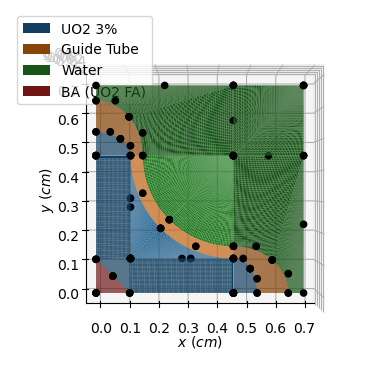

In [45]:
# Plot final mesh
ax = mesh.plot()
ax.view_init(90, -90, 0)
plt.legend()
#plt.tight_layout()
plt.savefig("./figs/four_lobe.png", dpi=3000)
plt.show()